# 1. Preparando o Ambiente de Análise 🛠️

Nesta etapa inicial, **eu configurei** as ferramentas que usarei para inspecionar os dados. Importei bibliotecas essenciais de visualização (`seaborn`, `matplotlib`) e defini os caminhos relativos para garantir que o notebook encontre o arquivo CSV gerado pelo meu pipeline de engenharia de dados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração de estilo visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Caminhos (ajustando para rodar de dentro da pasta notebooks)
PROCESSED_PATH = '../data/processed/dataset_espelhos.csv'
RAW_PATH = '../data/raw/'
    
print("Bibliotecas importadas e caminhos definidos.")

Bibliotecas importadas e caminhos definidos.


# 2. Carregamento do Dataset Processado 📂

Aqui, **carreguei o resultado final** da etapa de ingestão de dados. Meu objetivo foi confirmar se o script `run_ingestion.py` gerou o arquivo corretamente e visualizar as primeiras linhas para ter uma noção imediata da estrutura tabular que consegui extrair dos PDFs.

In [2]:
# Carregar o dataset gerado pelo pipeline
try:
    df = pd.read_csv(PROCESSED_PATH)
    print(f"✅ Dataset carregado com sucesso! Dimensões: {df.shape}")
except FileNotFoundError:
    print("❌ Arquivo não encontrado. Verifique se rodou o 'run_ingestion.py'.")

# Mostrar as primeiras linhas
df.head(25) # Mostra todos já que são poucos

✅ Dataset carregado com sucesso! Dimensões: (23, 14)


,Nome_Arquivo,Idade,Sexo,Justificativa_Internacao,Evolucao,Sinais_Vitais,Necessidade_Dialise,Sinais_Vitais_O2_Suporte,Instabilidade_Hemodinamica,Hemorragia_Ativa,Suspeita_Infecciosa,Oncologia_Fora_Perfil,Sinais_Gastro_Hepato,CID_10
0,CML.pdf,72,F,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,Data/Hora: 10/10/2025 10:14\n Profissional ...,NaN,1,1,1,0,0,0,1,NaN
1,CWSS.pdf,42,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,D/H: 08/10/2025 11:32\n P ...,NaN,1,0,0,0,0,0,1,NaN
2,DJA.pdf,46,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,D/H: 03/09/2025 13:17\n P ...,NaN,0,0,0,0,0,0,0,NaN
3,EAS.pdf,49,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,D/H: 25/09/2025 13:26\n P ...,NaN,1,1,0,0,1,0,1,NaN
4,EAS_Gastro.pdf,49,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,D/H: 25/09/2025 13:26\n P ...,NaN,1,1,0,0,1,0,1,NaN
5,ECL.pdf,43,F,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,Data/Hora: 26/10/2025 10:25\n Profissional ...,NaN,0,0,0,1,0,0,1,NaN
6,EES.pdf,38,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,PACIENTE REFERE QUE HÁ 20 DIAS EVOLUIU COM QUA...,NaN,1,1,0,1,0,0,1,NaN
7,EFC.pdf,29,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,"EVOLUO PACIENTE EM LEITO DE ALA AMARELA, ACOMP...",NaN,1,0,1,0,0,0,1,NaN
8,EJA.pdf,43,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,CONDIÇÕES QUE JUSTIFIQUEM A INTERNAÇÃO:\n P...,NaN,1,1,0,1,0,0,1,NaN
9,EM_GASTRO.pdf,80,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,Data/Hora: 19/12/2025 02:47\n Profis...,NaN,0,0,1,1,0,0,0,NaN


# 3. Raio-X da Qualidade dos Dados (Valores Nulos) 🔍

Precisava entender a integridade dos dados extraídos. **Utilizei um mapa de calor (heatmap)** para visualizar onde estão os "buracos" (dados nulos).

* **Minha intenção:** Descobrir se falhas na extração de campos específicos (como Idade ou Texto Diagnóstico) são isoladas ou sistêmicas em todo o dataset.

--- Informações do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nome_Arquivo                23 non-null     object 
 1   Idade                       23 non-null     int64  
 2   Sexo                        23 non-null     object 
 3   Justificativa_Internacao    23 non-null     object 
 4   Evolucao                    23 non-null     object 
 5   Sinais_Vitais               0 non-null      float64
 6   Necessidade_Dialise         23 non-null     int64  
 7   Sinais_Vitais_O2_Suporte    23 non-null     int64  
 8   Instabilidade_Hemodinamica  23 non-null     int64  
 9   Hemorragia_Ativa            23 non-null     int64  
 10  Suspeita_Infecciosa         23 non-null     int64  
 11  Oncologia_Fora_Perfil       23 non-null     int64  
 12  Sinais_Gastro_Hepato        23 non-null     int64  
 13  CID_

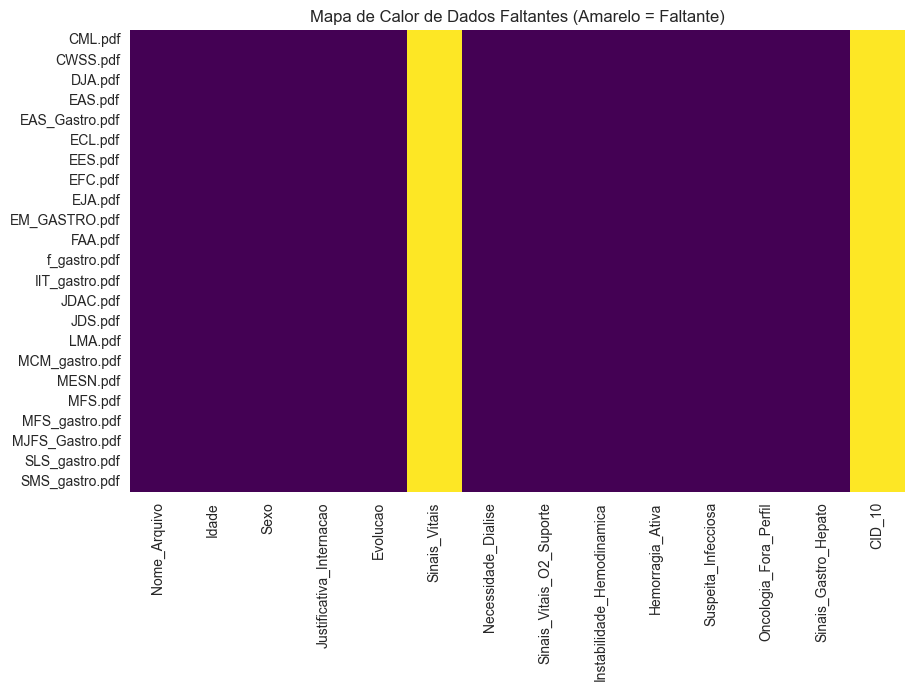

In [3]:
# Verificar tipos de dados e valores nulos
print("--- Informações do DataFrame ---")
df.info()

print("\n--- Contagem de Valores Nulos ---")
print(df.isnull().sum())

# Visualizar onde estão os nulos (Mapa de Calor)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=df['Nome_Arquivo'])
plt.title("Mapa de Calor de Dados Faltantes (Amarelo = Faltante)")
plt.show()

# 4. Investigação de Erros de Encoding (Artefatos de PDF) 🛑

Durante o desenvolvimento, **notei que alguns PDFs antigos** geravam caracteres estranhos como `(cid:`. Criei este filtro para quantificar quantos arquivos foram afetados por esse problema de *parsing*. Isso demonstra a "sujeira" real dos dados legados com a qual tive que lidar.

# 5. Validação das Flags Clínicas (Regras de Negócio) 🏥

Aqui, **plotei a distribuição** das principais variáveis de risco que meu algoritmo extraiu via *Regex*.

* **O que eu busquei validar:** Queria confirmar se o sistema estava conseguindo identificar corretamente pacientes com **Necessidade de Diálise** ou **Uso de O2**, que são os principais critérios de exclusão do protocolo.

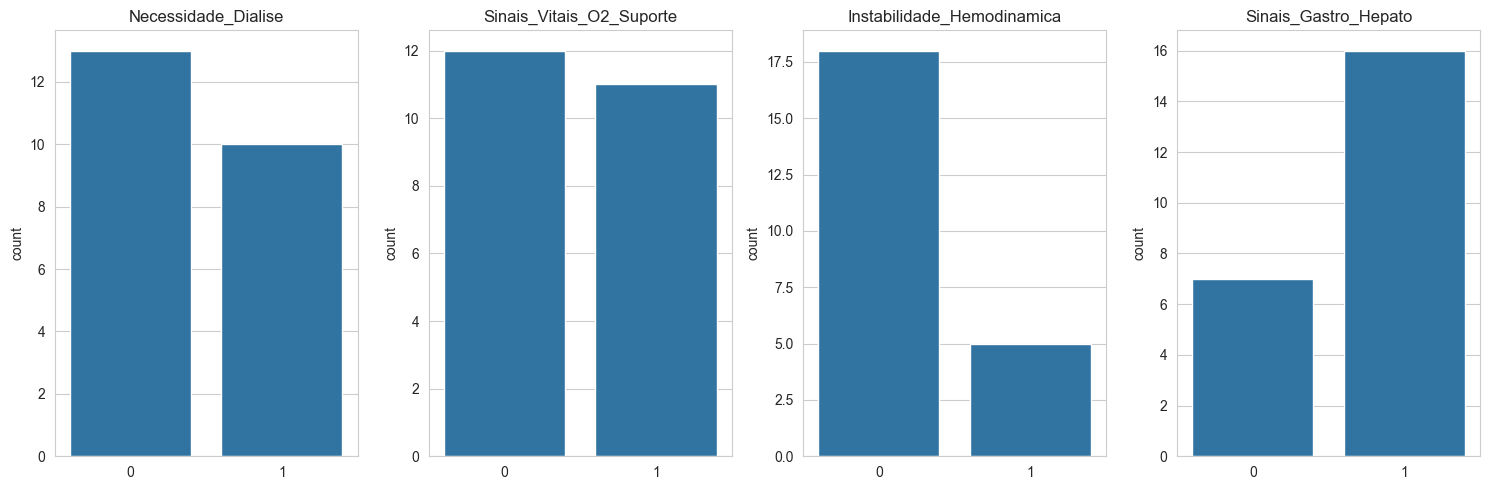

In [4]:
# Colunas binárias (Flags de risco)
flags = ['Necessidade_Dialise', 'Sinais_Vitais_O2_Suporte', 
         'Instabilidade_Hemodinamica', 'Sinais_Gastro_Hepato']

# Plotar a frequência de cada flag
plt.figure(figsize=(15, 5))
for i, col in enumerate(flags):
    plt.subplot(1, 4, i+1)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xlabel("")
plt.tight_layout()
plt.show()

# 6. Análise de Falhas Totais de Extração ⚠️

Identifiquei arquivos onde meu parser **não conseguiu encontrar o bloco de texto clínico**. Isolei esses casos para entender se eram problemas de layout (ex: prontuários com formatação diferente) e para documentar as limitações atuais da ferramenta de extração.

# 7. Auditoria de Idades Suspeitas (Correção de OCR) 🕵️‍♂️

Como estamos tratando de uma enfermaria adulta, idades menores que 18 anos são, na maioria, erros de leitura do OCR (ex: o número `71` sendo lido como `1`).

**Minha estratégia:** Filtrei esses casos e imprimi o texto bruto original. Isso me permitiu fazer uma "engenharia reversa" para descobrir quais caracteres estranhos estavam quebrando a leitura da idade e corrigir o limpador de texto posteriormente.

In [ ]:
# Carregar dados
df = pd.read_csv('../data/processed/dataset_espelhos.csv')

# Filtrar casos com idade suspeita (menor que 18 anos) para auditoria
suspeitos = df[df['Idade'] == 51]

print(f"Total de casos suspeitos (Idade < 18): {len(suspeitos)}")

# Vamos olhar o texto bruto desses casos para descobrir o caractere "ladrão" de idade
for index, row in suspeitos.iterrows():
    print(f"\n--- Arquivo: {row['Nome_Arquivo']} | Idade Extraída: {row['Idade']} ---")
    # Mostra os primeiros 100 caracteres do diagnóstico para vermos o padrão da idade
    print(f"Texto Inicial: {row['Diagnostico_Texto_Livre'][:150]}...")

Esse caso em específico verifiquei que a idade está correta e o paciente tem 14 anos.